# dynSystemSim.ipynb

Structured notebook for **single-run simulation** of nonlinear dynamical systems:

- Integration (RK45 adaptive, RK4 fixed, symplectic Verlet/Forest-Ruth)
- Time series (Tab 2)
- Phase portrait (Tab 1)
- Lyapunov spectrum (Tab 1)

Built-in systems: **Lorenz**, **Rossler**, **Henon-Heiles**.
Custom systems use SymPy expressions in `eq_lines`.

Designed to be driven by a **StaticParamsConfig.json** export from the Streamlit app.


In [1]:
# --- Imports + project root wiring ---
import json
from pathlib import Path
import sys

import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

PROJECT_ROOT = None
for candidate in [Path.cwd()] + list(Path.cwd().parents):
    if (candidate / "core").is_dir() and (candidate / "plotting").is_dir():
        PROJECT_ROOT = candidate
        break
if PROJECT_ROOT is None:
    raise FileNotFoundError("Could not locate repo root (missing core/ and plotting/)")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from core.solver import integrate_system, integrate_system_rk4
from core.symplectic_solver import integrate_system_symplectic_verlet, integrate_system_symplectic_fr
from core.lyapunov import compute_lyapunov_spectrum
from core.lorenz_system_rhs import lorenz_rhs
from core.rossler_system_rhs import rossler_rhs
from core.henon_heiles_system_rhs import henon_heiles_rhs, henon_heiles_dq_dt, henon_heiles_dp_dt
from core.jacobians_fixed_systems import henon_heiles_jac, lorenz_jac, rossler_jac

from plotting.plotting import phase_portrait

print("OK: imports loaded.")


OK: imports loaded.


## 1) Load config (StaticParamsConfig.json)

If you exported a config from the app, place it next to this notebook as `StaticParamsConfig.json`
(or change the path below).


In [2]:
# --- Load StaticParamsConfig.json (if present). Otherwise use a default config. ---
CONFIG_PATH = Path("StaticParamsConfig(4).json")

def load_config(path: Path) -> dict:
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

if CONFIG_PATH.exists():
    cfg = load_config(CONFIG_PATH)
    print(f"Loaded config: {CONFIG_PATH.resolve()}")
else:
    # Default fallback config (Lorenz). Change system_key to "henon_heiles"
    # and solver_kind to "symplectic_verlet" to test the Hamiltonian path.
    cfg = {
        "schema_version": "1.0",
        "system": {
            "system_key": "lorenz",
            "var_names": ["x", "y", "z"],
            "eq_lines": [],
            "params": {"sigma": 10.0, "rho": 28.0, "beta": 8.0 / 3.0},
        },
        "integration": {
            "t0": 0.0, "tf": 50.0, "dt": 0.01,
            "y0": [1.0, 1.0, 1.0],
            "solver_kind": "ivp",
            "solve_options": {"rtol": 3e-4, "atol": 1e-6},
        },
        "postprocess": {"transient_steps": 0},
        "plots": {
            "plot_mode": "2D phase plane",
            "phase_axes": {"x_idx": 0, "y_idx": 1, "z_idx": 2},
            "time_series_indices": [0, 1, 2],
        },
        "lyapunov": {
            "enabled": True,
            "settings": {
                "t_transient": 10.0,
                "t_measure": 40.0,
                "transient_steps": 1000,
                "transient_fraction": 0.2,
                "qr_interval": 0.1,
                "qr_every_steps": 1,
                "jacobian": "analytic",
                "fd_eps": 1e-8,
            },
        },
    }
    print("No StaticParamsConfig.json found - using default Lorenz config.")

cfg


Loaded config: /home/odygoundi/Documents/nds-simulator/examples/StaticParamsConfig(4).json


{'schema_version': '1.0',
 'app': {'name': 'nlds-simulator',
  'commit': '89f1a4d7aa6a3c8fe73d28aa44321a25d6e2078f'},
 'timestamp_utc': '2026-01-21T11:36:15Z',
 'system': {'system_key': 'henon_heiles',
  'var_names': ['q1', 'q2', 'p1', 'p2'],
  'eq_lines': ['p1',
   'p2',
   '-q1 - 2*lambda*q1*q2',
   '-q2 - lambda*(q1**2 - q2**2)'],
  'params': {'lambda': 2.5}},
 'integration': {'t0': 0.0,
  'tf': 1500.0,
  'dt': 0.01,
  'y0': [0.1, 0.0, 0.0, 0.1],
  'solver_kind': 'symplectic_fr',
  'solve_options': {'rtol': 1e-06, 'atol': 1e-08}},
 'postprocess': {'transient_steps': 10000},
 'plots': {'plot_mode': '2D phase plane',
  'phase_axes': {'x_idx': 0, 'y_idx': 1, 'z_idx': None}},
 'lyapunov': {'enabled': True,
  'settings': {'dt': 0.01,
   't_transient': 450.0,
   't_measure': 1050.0,
   'transient_steps': 45000,
   'transient_fraction': 0.3,
   'qr_every_steps': 10,
   'qr_interval': 0.1,
   'jacobian': 'analytic',
   'fd_eps': 1e-08}}}

## 2) Build RHS (built-in or custom)

Supported `system_key`:
- `"lorenz"`
- `"rossler"`
- `"henon_heiles"`
- `"custom"` (uses SymPy expressions in `eq_lines`)

Symplectic solvers are supported for:
- `henon_heiles`
- `custom` Hamiltonian systems in separable form


In [3]:
SAFE_FUNCS = {
    "sin": sp.sin, "cos": sp.cos, "tan": sp.tan,
    "exp": sp.exp, "log": sp.log, "sqrt": sp.sqrt,
    "abs": sp.Abs,
}


def parse_params_text(text: str) -> dict:
    params = {}
    for line in (text or "").splitlines():
        line = line.strip()
        if not line:
            continue
        if "=" not in line:
            raise ValueError(f"Parameter line must be name=value. Got: {line!r}")
        name, val = line.split("=", 1)
        name = name.strip()
        val = val.strip()
        if name.lower() == "t":
            raise ValueError("Parameter name 't' is reserved.")
        params[name] = float(val)
    return params


def build_custom_rhs_and_jac(var_names, eq_lines, params, use_jac=True):
    n = len(var_names)
    if len(eq_lines) != n:
        raise ValueError(f"Need exactly {n} equations. Got {len(eq_lines)}.")

    t_sym = sp.Symbol("t")
    var_syms = sp.symbols(var_names)
    param_syms = {k: sp.Symbol(k) for k in (params or {}).keys()}

    locals_dict = {
        **SAFE_FUNCS,
        "t": t_sym,
        **{name: sym for name, sym in zip(var_names, var_syms)},
        **param_syms,
    }

    exprs = []
    for i, line in enumerate(eq_lines):
        s = (line or "").strip()
        if not s:
            raise ValueError(f"Equation {i + 1} is empty.")
        exprs.append(sp.sympify(s, locals=locals_dict))

    args = [t_sym] + list(var_syms) + [param_syms[k] for k in params.keys()]
    f_rhs = sp.lambdify(args, exprs, modules=["numpy"])

    f_jac = None
    if use_jac:
        J = sp.Matrix(exprs).jacobian(var_syms)
        f_jac = sp.lambdify(args, J, modules=["numpy"])

    param_values = [float(params[k]) for k in params.keys()]

    def rhs(t, y):
        vals = [float(t)] + list(np.asarray(y, dtype=float)) + param_values
        out = f_rhs(*vals)
        return np.array(out, dtype=float)

    if f_jac is None:
        return rhs, None

    def jac(t, y):
        vals = [float(t)] + list(np.asarray(y, dtype=float)) + param_values
        return np.array(f_jac(*vals), dtype=float)

    return rhs, jac


def build_custom_symplectic_functions(var_names, eq_lines, params):
    n = len(var_names)
    if n % 2 != 0:
        raise ValueError("Symplectic solvers require an even number of variables [q..., p...].")
    if len(eq_lines) != n:
        raise ValueError(f"Need exactly {n} equations. Got {len(eq_lines)}.")

    n_q = n // 2
    t_sym = sp.Symbol("t")
    var_syms = sp.symbols(var_names)
    q_syms = var_syms[:n_q]
    p_syms = var_syms[n_q:]
    param_syms = {k: sp.Symbol(k) for k in (params or {}).keys()}

    locals_dict = {
        **SAFE_FUNCS,
        "t": t_sym,
        **{name: sym for name, sym in zip(var_names, var_syms)},
        **param_syms,
    }

    exprs = []
    for i, line in enumerate(eq_lines):
        s = (line or "").strip()
        if not s:
            raise ValueError(f"Equation {i + 1} is empty.")
        exprs.append(sp.sympify(s, locals=locals_dict))

    dq_exprs = exprs[:n_q]
    dp_exprs = exprs[n_q:]
    q_set = set(q_syms)
    p_set = set(p_syms)

    for i, expr in enumerate(dq_exprs):
        bad = expr.free_symbols & q_set
        if bad:
            bad_names = ", ".join(sorted(sym.name for sym in bad))
            raise ValueError(f"dq/dt equation {i + 1} depends on q vars: {bad_names}.")

    for i, expr in enumerate(dp_exprs):
        bad = expr.free_symbols & p_set
        if bad:
            bad_names = ", ".join(sorted(sym.name for sym in bad))
            eq_idx = n_q + i + 1
            raise ValueError(f"dp/dt equation {eq_idx} depends on p vars: {bad_names}.")

    dq_args = [t_sym] + list(p_syms) + [param_syms[k] for k in params.keys()]
    dp_args = [t_sym] + list(q_syms) + [param_syms[k] for k in params.keys()]
    f_dq = sp.lambdify(dq_args, dq_exprs, modules=["numpy"])
    f_dp = sp.lambdify(dp_args, dp_exprs, modules=["numpy"])
    param_values = [float(params[k]) for k in params.keys()]

    def dq_dt(t, p):
        p_arr = np.asarray(p, dtype=float)
        if p_arr.size != n_q:
            raise ValueError(f"dq_dt expects {n_q} p variables, got {p_arr.size}.")
        vals = [float(t)] + list(p_arr) + param_values
        out = f_dq(*vals)
        return np.array(out, dtype=float)

    def dp_dt(t, q):
        q_arr = np.asarray(q, dtype=float)
        if q_arr.size != n_q:
            raise ValueError(f"dp_dt expects {n_q} q variables, got {q_arr.size}.")
        vals = [float(t)] + list(q_arr) + param_values
        out = f_dp(*vals)
        return np.array(out, dtype=float)

    return dq_dt, dp_dt


def build_rhs_and_jac(cfg: dict):
    sys_cfg = cfg.get("system", {})
    key = str(sys_cfg.get("system_key", "")).lower().strip()
    params = sys_cfg.get("params") or {}
    if not params and sys_cfg.get("params_text"):
        params = parse_params_text(sys_cfg.get("params_text"))
    params = {str(k): float(v) for k, v in (params or {}).items()}

    var_names = sys_cfg.get("var_names") or []
    eq_lines = sys_cfg.get("eq_lines") or []

    if key == "lorenz":
        return (
            lambda t, y: lorenz_rhs(t, y, **params),
            lambda t, y: lorenz_jac(t, y, **params),
            {"key": key, "params": params, "var_names": var_names, "eq_lines": eq_lines},
        )
    if key == "rossler":
        return (
            lambda t, y: rossler_rhs(t, y, **params),
            lambda t, y: rossler_jac(t, y, **params),
            {"key": key, "params": params, "var_names": var_names, "eq_lines": eq_lines},
        )
    if key == "henon_heiles":
        if not params:
            params = {"lambda": 1.0}
        if not var_names:
            var_names = ["q1", "q2", "p1", "p2"]
        if not eq_lines:
            eq_lines = [
                "p1",
                "p2",
                "-q1 - 2*lambda*q1*q2",
                "-q2 - lambda*(q1**2 - q2**2)",
            ]
        return (
            lambda t, y: henon_heiles_rhs(t, y, **params),
            lambda t, y: henon_heiles_jac(t, y, **params),
            {"key": key, "params": params, "var_names": var_names, "eq_lines": eq_lines},
        )
    if key == "custom":
        if len(var_names) == 0 or len(eq_lines) == 0:
            raise ValueError("Custom system requires var_names and eq_lines in config.")
        if len(eq_lines) != len(var_names):
            raise ValueError("Custom system: eq_lines must match var_names length.")
        auto_jac = bool(sys_cfg.get("auto_jacobian", False))
        use_jac = bool(sys_cfg.get("use_jacobian", False))
        rhs, jac = build_custom_rhs_and_jac(var_names, eq_lines, params, use_jac=auto_jac and use_jac)
        return rhs, jac, {"key": key, "params": params, "var_names": var_names, "eq_lines": eq_lines}

    raise ValueError(f"Unknown system_key: {key!r}")


rhs, jac, sys_meta = build_rhs_and_jac(cfg)
print("OK: RHS built.")


OK: RHS built.


## 3) Integrate the system


In [4]:
integ = cfg.get("integration", {})
t0 = float(integ.get("t0", 0.0))
tf = float(integ.get("tf", 50.0))
dt = float(integ.get("dt", 0.01))
y0 = np.asarray(integ.get("y0", [1.0, 1.0, 1.0]), dtype=float)

solver_kind = str(integ.get("solver_kind", "ivp")).lower().strip()
solve_opts = integ.get("solve_options") or {}

if solver_kind not in ("ivp", "rk4", "symplectic_verlet", "symplectic_fr"):
    print(f"Unknown solver_kind {solver_kind!r}; using RK45.")
    solver_kind = "ivp"

use_symplectic = solver_kind in ("symplectic_verlet", "symplectic_fr")
dq_dt = None
dp_dt = None

if use_symplectic:
    if sys_meta["key"] == "henon_heiles":
        lam = sys_meta["params"].get("lambda", sys_meta["params"].get("lam", 1.0))
        def dq_dt(t, p):
            return henon_heiles_dq_dt(t, p, lam=lam)
        def dp_dt(t, q):
            return henon_heiles_dp_dt(t, q, lam=lam)
    elif sys_meta["key"] == "custom":
        try:
            dq_dt, dp_dt = build_custom_symplectic_functions(
                sys_meta["var_names"],
                sys_meta["eq_lines"],
                sys_meta["params"],
            )
        except Exception as exc:
            print(f"Symplectic check failed: {exc}")
            use_symplectic = False
    else:
        print("Symplectic solver requested but system is not Hamiltonian. Using RK45.")
        use_symplectic = False

if use_symplectic:
    if solver_kind == "symplectic_verlet":
        sol = integrate_system_symplectic_verlet(
            rhs,
            (t0, tf),
            y0,
            t_step=dt,
            dp_dt=dp_dt,
            dq_dt=dq_dt,
        )
    else:
        sol = integrate_system_symplectic_fr(
            rhs,
            (t0, tf),
            y0,
            t_step=dt,
            dp_dt=dp_dt,
            dq_dt=dq_dt,
        )
elif solver_kind == "rk4":
    sol = integrate_system_rk4(rhs, (t0, tf), y0, t_step=dt)
else:
    sol = integrate_system(rhs, (t0, tf), y0, t_step=dt, **solve_opts)

print("success:", sol.success)
print("message:", sol.message)
print("t.shape:", sol.t.shape, "y.shape:", sol.y.shape)

t = sol.t
Y = sol.y  # shape (n_states, n_points)


success: True
message: Symplectic Forest–Ruth (FR) integration completed.
t.shape: (150001,) y.shape: (4, 150001)


## 4) Tab 2 - Time series (post-transient)


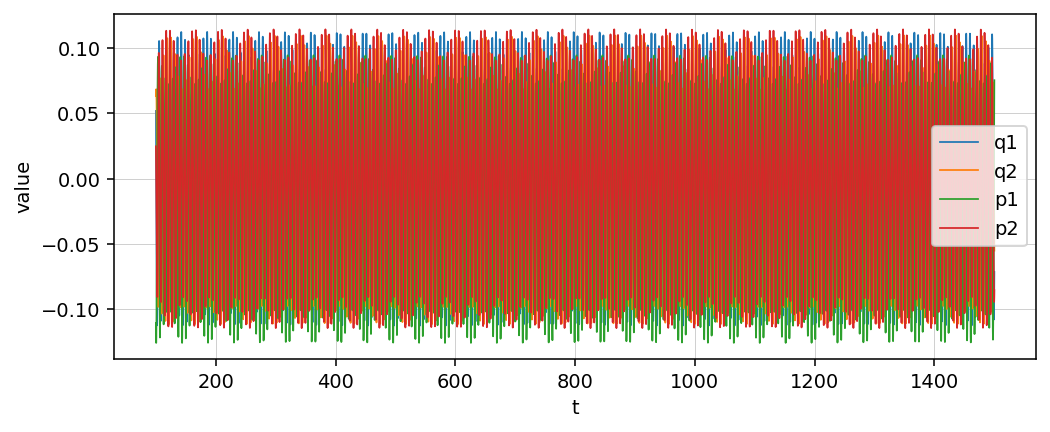

In [5]:
post = cfg.get("postprocess") or {}
transient_steps = int(post.get("transient_steps", 0))
transient_steps = max(0, min(transient_steps, Y.shape[1] - 1))

t_plot = t[transient_steps:]
Y_plot = Y[:, transient_steps:]

var_names = (cfg.get("system") or {}).get("var_names") or [f"y{i+1}" for i in range(Y.shape[0])]
plots_cfg = cfg.get("plots") or {}
ts_indices = plots_cfg.get("time_series_indices") or list(range(Y.shape[0]))

ts_indices = [int(i) for i in ts_indices if int(i) < Y.shape[0]]
if not ts_indices:
    ts_indices = list(range(Y.shape[0]))

fig, ax = plt.subplots(figsize=(8.5, 3.2))
fig.set_dpi(140)
for idx in ts_indices:
    ax.plot(t_plot, Y_plot[idx, :], linewidth=0.9, label=var_names[idx])
ax.set_xlabel("t")
ax.set_ylabel("value")
ax.grid(True, linewidth=0.3)
ax.legend(loc="best")
plt.show()


## 5) Tab 1 - Phase portrait (2D)

Uses `phase_portrait` from `plotting/plotting.py`. If the config is set to 3D,
we still plot a 2D projection using `x_idx` and `y_idx`.


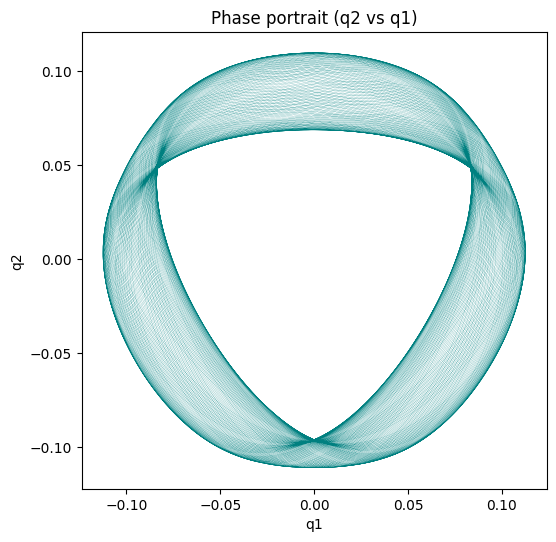

In [6]:
plots_cfg = cfg.get("plots") or {}
axes_cfg = plots_cfg.get("phase_axes") or {"x_idx": 0, "y_idx": 1}
xi = int(axes_cfg.get("x_idx", 0))
yi = int(axes_cfg.get("y_idx", 1))
plot_mode = str(plots_cfg.get("plot_mode", "2D phase plane"))

if "3d" in plot_mode.lower():
    print("Plot mode is 3D; using 2D projection for phase portrait.")

phase_portrait(
    Y,
    x_index=xi,
    y_index=yi,
    transient_steps=transient_steps,
    xlabel=var_names[xi],
    ylabel=var_names[yi],
    title=f"Phase portrait ({var_names[yi]} vs {var_names[xi]})",
)


## 6) Tab 1 - Lyapunov spectrum (optional)


In [7]:
lyap_cfg = cfg.get("lyapunov") or {}
if not bool(lyap_cfg.get("enabled", True)):
    print("Lyapunov disabled in config.")
else:
    s = lyap_cfg.get("settings") or {}
    total_time = float(tf) - float(t0)

    t_transient = s.get("t_transient", None)
    t_measure = s.get("t_measure", None)
    if t_transient is None or t_measure is None:
        transient_steps = s.get("transient_steps", None)
        transient_fraction = s.get("transient_fraction", None)
        if transient_steps is not None:
            t_transient = float(transient_steps) * float(dt)
        elif transient_fraction is not None:
            t_transient = float(transient_fraction) * total_time
        else:
            t_transient = 0.0
        t_measure = total_time - float(t_transient)

    t_transient = float(t_transient)
    t_measure = float(t_measure)

    qr_every_steps = int(s.get("qr_every_steps", 1))
    qr_interval = float(s.get("qr_interval", 0.0))
    if qr_every_steps <= 0:
        qr_every_steps = 1
    if qr_interval > 0.0 and qr_every_steps == 1:
        qr_every_steps = max(1, int(round(qr_interval / dt)))

    jac_mode = str(s.get("jacobian", ""))
    jac_mode = jac_mode.lower().strip()
    fd_eps = float(s.get("fd_eps", 1e-8))

    jac_to_use = jac if (jac_mode == "analytic" and jac is not None) else None
    if jac_mode == "analytic" and jac is None:
        print("Analytic Jacobian requested but not available; using finite differences.")

    result = compute_lyapunov_spectrum(
        rhs=rhs,
        x0=y0,
        t0=t0,
        dt=dt,
        t_transient=t_transient,
        t_measure=t_measure,
        qr_every_steps=qr_every_steps,
        solve_options=solve_opts,
        jac=jac_to_use,
        fd_eps=fd_eps,
    )

    print("Lyapunov exponents:")
    print(np.asarray(result.lambdas))


Lyapunov exponents:
[ 0.00108044  0.00102416 -0.00108029 -0.00102431]
